In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn. preprocessing import LabelEncoder
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.metrics import Precision, Recall

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.metrics import Precision, Recall


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

2025-10-24 15:59:22.958774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761321563.221236      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761321563.296442      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
dfhotels = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/hotels.csv')

In [3]:
dfusers = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/users.csv')

In [4]:
dfreviews = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/reviews.csv')


# step 1: merge the tables to deal with all the data once

In [5]:

#  Merge hotels and reviews on 'hotel_id'
hotel_reviews = pd.merge(dfreviews, dfhotels, on='hotel_id', how='left')

#  Merge the result with users on 'user_id'
merged_df = pd.merge(hotel_reviews, dfusers, on='user_id', how='left')

# (Optional) Save the merged dataset
merged_df.to_csv('/kaggle/working/merged_hotel_reviews.csv', index=False)

Dataset Shape: (50000, 29)

Missing Values:
 review_id               0
star_rating             0
traveller_type          0
age_group               0
country_y               0
user_gender             0
value_for_money_base    0
staff_base              0
location_base           0
facilities_base         0
dtype: int64

Data Types:
 review_id              int64
user_id                int64
hotel_id               int64
review_date           object
score_overall        float64
score_cleanliness    float64
score_comfort        float64
score_facilities     float64
score_location       float64
score_staff          float64
dtype: object


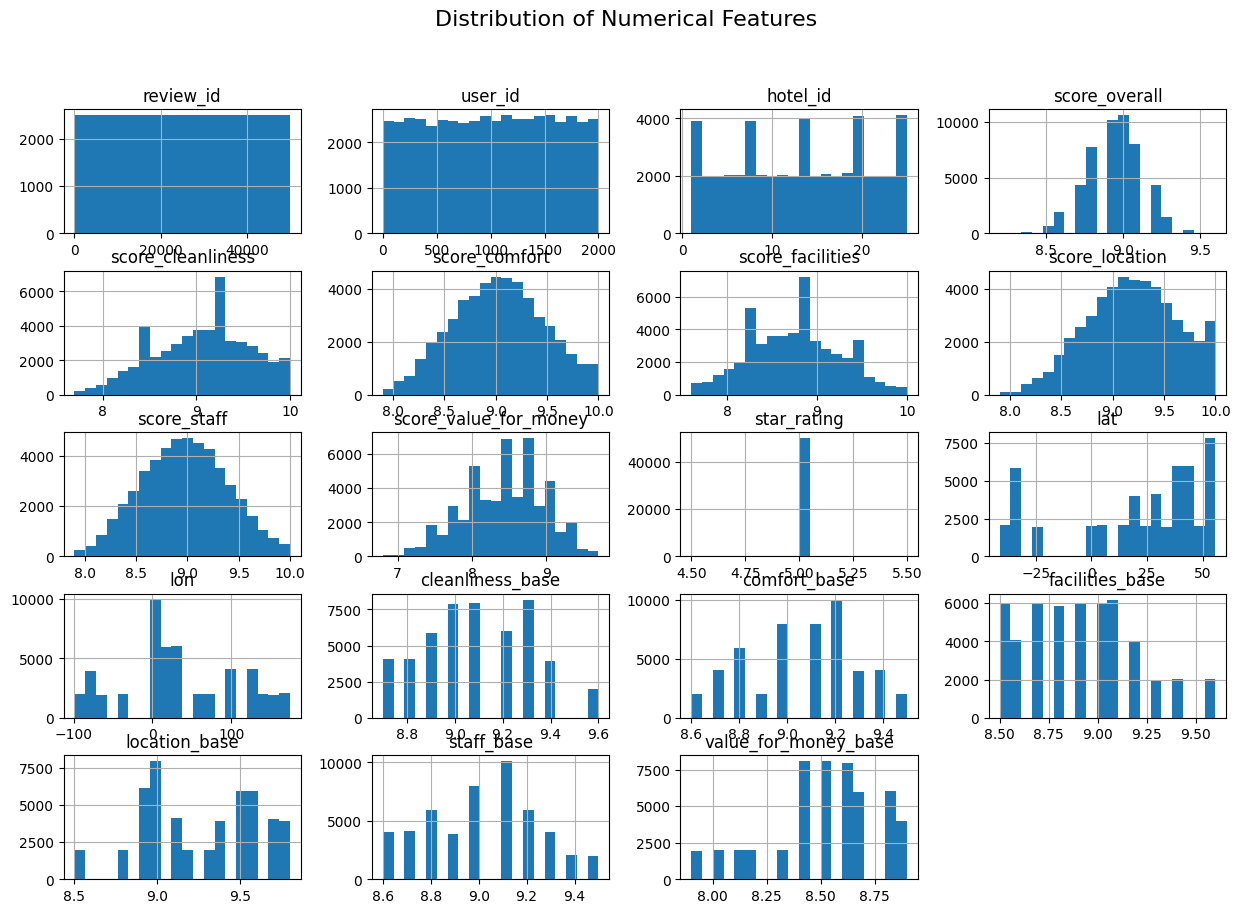

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


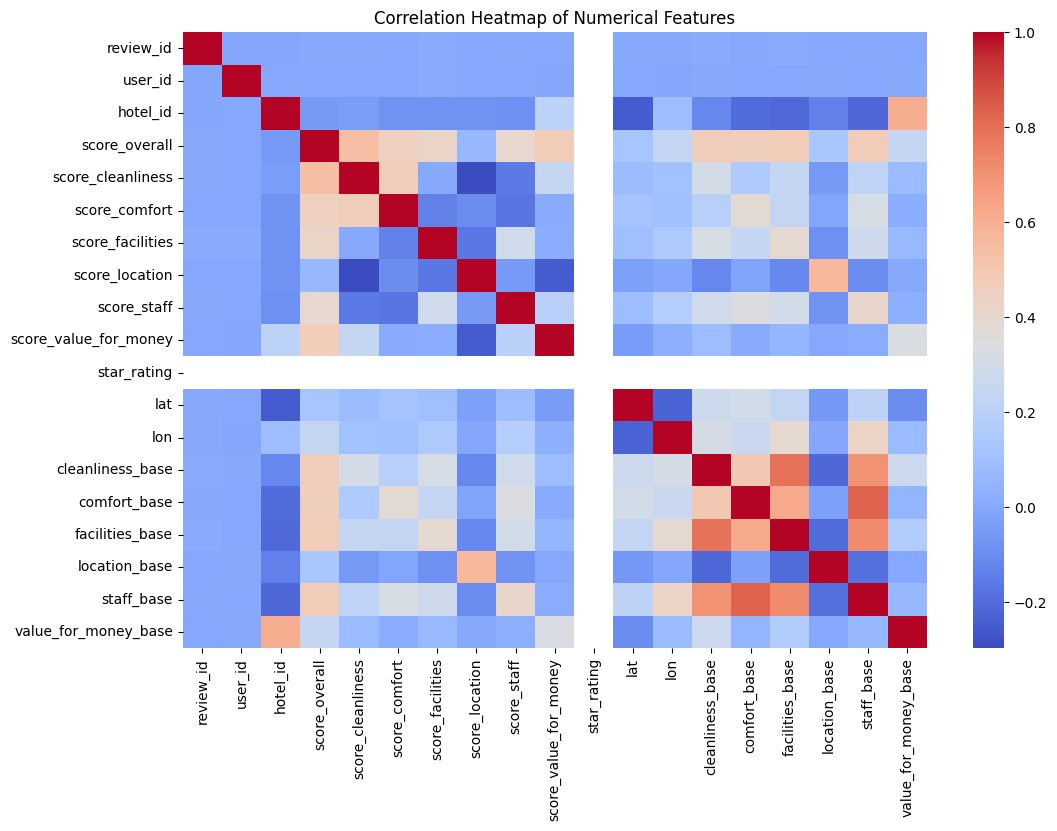

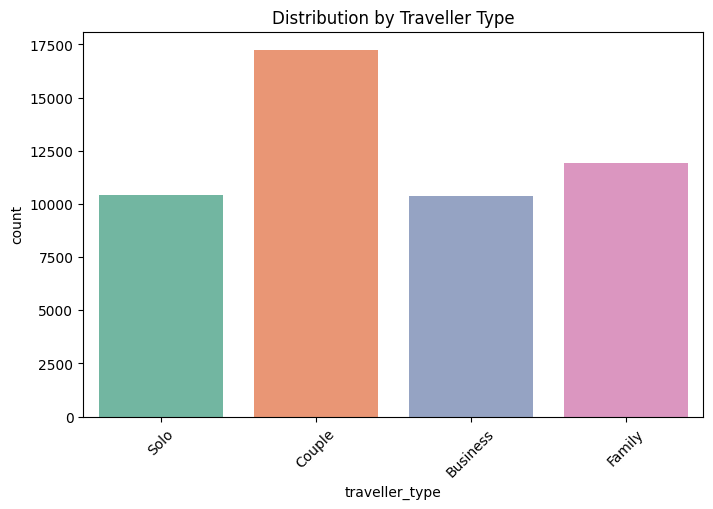

In [6]:
# ============================
# 📊 Basic EDA Visualizations
# ============================

# Overview of dataset
print("Dataset Shape:", merged_df.shape)
print("\nMissing Values:\n", merged_df.isnull().sum().sort_values(ascending=False).head(10))
print("\nData Types:\n", merged_df.dtypes.head(10))

# --- 1. Distribution of numerical features ---
num_cols = merged_df.select_dtypes(include=['int64', 'float64']).columns
merged_df[num_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

# --- 2. Correlation Heatmap ---
plt.figure(figsize=(12, 8))
sns.heatmap(merged_df[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# --- 3. Distribution by traveler type (if available) ---
if 'traveller_type' in merged_df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=merged_df, x='traveller_type', palette='Set2')
    plt.title("Distribution by Traveller Type")
    plt.xticks(rotation=45)
    plt.show()


# Step 1: data cleaning
 ## 1: Inspect the dataset structure


* ### Shows how many rows and columns the dataset has


In [7]:

print("Dataset shape:", merged_df.shape)

Dataset shape: (50000, 29)


* ### Displays the column names, data types, and number of missing values.

In [8]:
print(merged_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   review_id              50000 non-null  int64  
 1   user_id                50000 non-null  int64  
 2   hotel_id               50000 non-null  int64  
 3   review_date            50000 non-null  object 
 4   score_overall          50000 non-null  float64
 5   score_cleanliness      50000 non-null  float64
 6   score_comfort          50000 non-null  float64
 7   score_facilities       50000 non-null  float64
 8   score_location         50000 non-null  float64
 9   score_staff            50000 non-null  float64
 10  score_value_for_money  50000 non-null  float64
 11  review_text            50000 non-null  object 
 12  hotel_name             50000 non-null  object 
 13  city                   50000 non-null  object 
 14  country_x              50000 non-null  object 
 15  st

#### *The output shows that the dataset has 50,000 rows and 29 columns, containing a mix of numeric and categorical data.All columns have non-null values (no missing data).There are 15 float columns, 4 integer columns, and 10 object (categorical or text) columns.The total memory usage is about 11.1 MB.*

* ### Summarizes the numeric and categorical data statistically.

In [9]:
# Numeric summary only
print(merged_df.describe())


          review_id       user_id      hotel_id  score_overall  \
count  50000.000000  50000.000000  50000.000000   50000.000000   
mean   25000.500000   1005.567540     13.051100       8.943460   
std    14433.901067    576.711855      7.203808       0.180878   
min        1.000000      1.000000      1.000000       8.200000   
25%    12500.750000    507.000000      7.000000       8.800000   
50%    25000.500000   1010.000000     13.000000       8.900000   
75%    37500.250000   1504.000000     19.000000       9.100000   
max    50000.000000   2000.000000     25.000000       9.600000   

       score_cleanliness  score_comfort  score_facilities  score_location  \
count       50000.000000   50000.000000      50000.000000    50000.000000   
mean            9.052558       9.024404          8.743062        9.176410   
std             0.504296       0.423927          0.498320        0.421086   
min             7.700000       7.900000          7.600000        7.900000   
25%             8.70

In [10]:
# Categorical/text summary only
print(merged_df.describe(include=['object']))


       review_date                                        review_text  \
count        50000                                              50000   
unique        2192                                              50000   
top     2025-07-17  Practice reduce young our because machine. Rec...   
freq            50                                                  1   

           hotel_name   city country_x user_gender      country_y age_group  \
count           50000  50000     50000       50000          50000     50000   
unique             25     25        25           3             25         5   
top     Nile Grandeur  Cairo     Egypt        Male  United States     25-34   
freq             2104   2104      2104       23630           6971     16322   

       traveller_type   join_date  
count           50000       50000  
unique              4        1200  
top            Couple  2023-01-17  
freq            17240         174  


#### ***Numeric summary**: all numeric columns are complete (no missing values). The scores (overall, cleanliness, comfort, etc.) are all in a tight, realistic range (~8–10)*

#### ***Categorical summary**: categorical columns (user_gender, age_group, traveller_type, country_x, country_y, city, etc.) have valid distinct categories and no nulls.*

#### ***Dates**: both review_date and join_date contain many unique values (over 2,000 and 1,200 respectively).*

* ### Shows the first few rows of the dataset to preview the data.

In [11]:
print(merged_df.head())


   review_id  user_id  hotel_id review_date  score_overall  score_cleanliness  \
0          1     1600         1  2022-10-07            8.7                8.6   
1          2      432         4  2020-03-24            9.1               10.0   
2          3      186        18  2023-12-18            8.8                9.7   
3          4     1403        19  2022-06-22            8.9                9.0   
4          5     1723        17  2022-07-02            9.1                8.9   

   score_comfort  score_facilities  score_location  score_staff  ...  \
0            8.7               8.5             9.0          8.8  ...   
1            9.1               9.0             8.6          9.4  ...   
2            8.8               8.3             8.7          8.1  ...   
3            8.8               8.5             9.6          9.1  ...   
4            9.5               9.3             8.3          9.4  ...   

   comfort_base facilities_base location_base staff_base value_for_money_base  \

## 2.Identify Missing Values
* ### Detect which columns have null values.

review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
review_text              0
hotel_name               0
city                     0
country_x                0
star_rating              0
lat                      0
lon                      0
cleanliness_base         0
comfort_base             0
facilities_base          0
location_base            0
staff_base               0
value_for_money_base     0
user_gender              0
country_y                0
age_group                0
traveller_type           0
join_date                0
dtype: int64


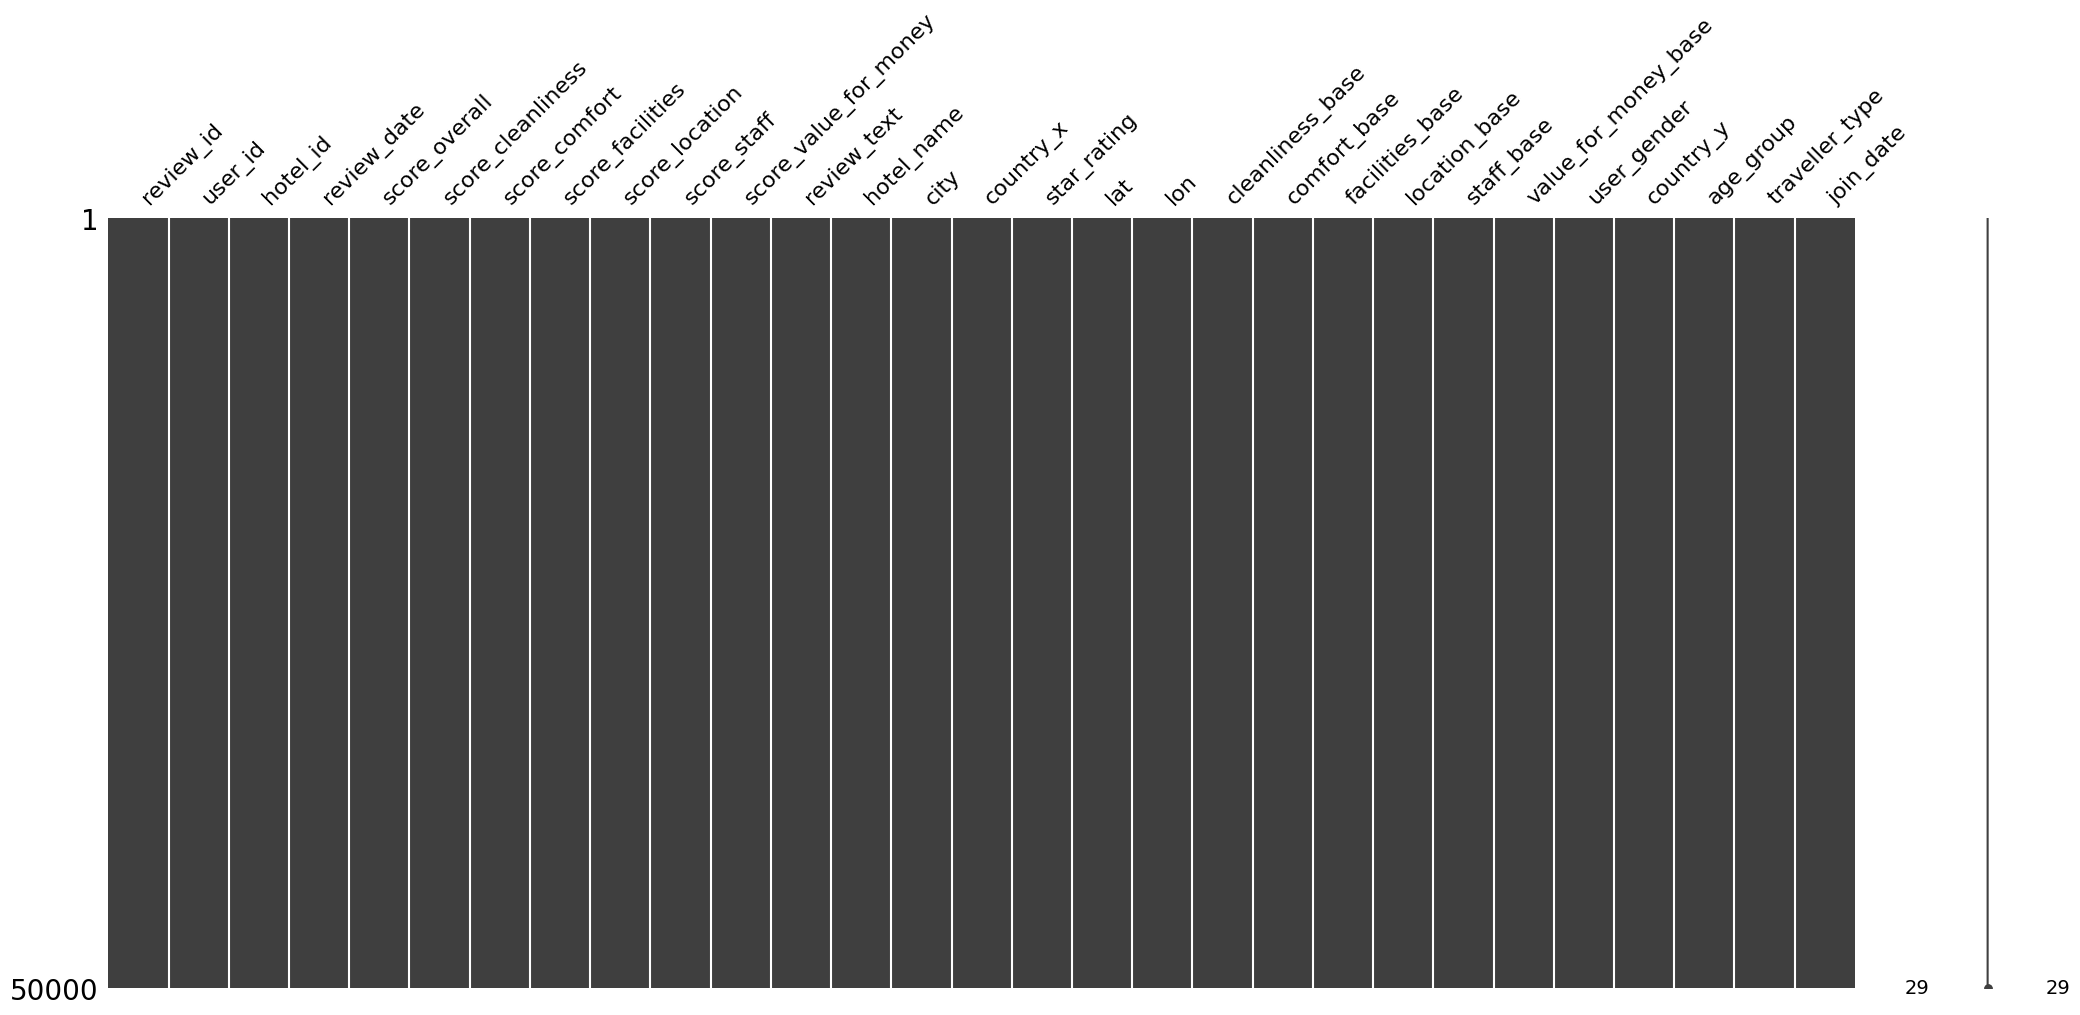

In [12]:
import missingno as msno
msno.matrix(merged_df)           # visualize missing patterns
print(merged_df.isnull().sum())  # numeric count per column

#### *NO null values*

 ## 3.Check for duplicate column names

In [13]:
print(merged_df.columns[merged_df.columns.duplicated()])


Index([], dtype='object')


#### *no duplicate column names*

 ## 4.Check for constant columns (same value in all rows)

In [14]:
constant_cols = [col for col in merged_df.columns if merged_df[col].nunique() == 1]
print("Constant columns:", constant_cols)


Constant columns: ['star_rating']


#### *all hotels have the same rating so we will drop this coloumn*

## 5.Check consistency

* ###  Check consistency in traveller_type 
    ###         Verified all traveller type entries ('Couple', 'Family', 'Solo', 'Business')

In [15]:
# --- Detect odd / inconsistent traveller_type entries ---

# Normalize all values temporarily
merged_df['traveller_type_normalized'] = merged_df['traveller_type'].str.strip().str.lower()

# See what the main categories are (by frequency)
print("Unique normalized categories and counts:\n")
print(merged_df['traveller_type_normalized'].value_counts())

# Find uncommon / misspelled categories (appear rarely)
threshold = 0.01 * len(merged_df)  # less than 1% of rows = probably typo
rare_values = merged_df['traveller_type_normalized'].value_counts()[
    merged_df['traveller_type_normalized'].value_counts() < threshold
].index

# Show rows that have those rare/odd values
odd_rows = merged_df[merged_df['traveller_type_normalized'].isin(rare_values)]
print("\nRows with inconsistent traveller_type values:\n")
display(odd_rows[['traveller_type']].drop_duplicates())
merged_df.drop(columns=['traveller_type_normalized'], inplace=True)


Unique normalized categories and counts:

traveller_type_normalized
couple      17240
family      11945
solo        10444
business    10371
Name: count, dtype: int64

Rows with inconsistent traveller_type values:



,traveller_type


#### *All are consistent with no duplicates, typos, or extra spaces.*

* ###  Check consistency in user_gender 
    ### Checked user gender categories ('Male', 'Female', 'Other')

In [16]:
# --- Detect odd / inconsistent user_gender entries ---

# 1. Create a temporary normalized column (for checking only)
merged_df['user_gender_normalized'] = merged_df['user_gender'].str.strip().str.lower()

# 2. Show the main gender categories by frequency
print("Unique normalized gender categories and counts:\n")
print(merged_df['user_gender_normalized'].value_counts())

# 3. Detect rare or misspelled entries (< 1% of total)
threshold = 0.01 * len(merged_df)
rare_values = merged_df['user_gender_normalized'].value_counts()[
    merged_df['user_gender_normalized'].value_counts() < threshold
].index

# 4. Display the actual rows that contain those odd entries
odd_rows = merged_df[merged_df['user_gender_normalized'].isin(rare_values)]
print("\nRows with inconsistent user_gender values:\n")
display(odd_rows[['user_gender']].drop_duplicates())

# 5. Remove the temporary column
merged_df.drop(columns=['user_gender_normalized'], inplace=True)


Unique normalized gender categories and counts:

user_gender_normalized
male      23630
female    21659
other      4711
Name: count, dtype: int64

Rows with inconsistent user_gender values:



,user_gender


#### *All are consistent and correctly formatted.*

* ### Check consistency in hotels country (country_x) 
    ### Verified hotel country names in country_x column

In [17]:
# --- Detect odd / inconsistent hotel country (country_x) entries ---

# 1. Create a temporary normalized column
merged_df['country_x_normalized'] = merged_df['country_x'].str.strip().str.lower()

# 2. Show unique normalized values and their counts
print("Unique normalized hotel countries and counts:\n")
print(merged_df['country_x_normalized'].value_counts())

# 3. Detect rare or misspelled entries (< 1% of total)
threshold = 0.01 * len(merged_df)
rare_values = merged_df['country_x_normalized'].value_counts()[
    merged_df['country_x_normalized'].value_counts() < threshold
].index

# 4. Show the actual inconsistent country names, if any
odd_rows = merged_df[merged_df['country_x_normalized'].isin(rare_values)]
print("\nRows with inconsistent country_x values:\n")
display(odd_rows[['country_x']].drop_duplicates())

# 5. Remove temporary helper column
merged_df.drop(columns=['country_x_normalized'], inplace=True)


Unique normalized hotel countries and counts:

country_x_normalized
egypt                   2104
south korea             2071
new zealand             2060
thailand                2055
nigeria                 2049
china                   2040
spain                   2039
united arab emirates    2035
germany                 2022
singapore               2015
mexico                  2004
united states           1998
france                  1993
india                   1989
south africa            1979
japan                   1971
italy                   1971
russia                  1970
canada                  1964
brazil                  1962
argentina               1956
australia               1954
netherlands             1949
turkey                  1948
united kingdom          1902
Name: count, dtype: int64

Rows with inconsistent country_x values:



,country_x


#### *All countries are clean, correctly spelled, and consistently formatted.*

* ### Check if all score columns fall within expected range (1–10)

In [18]:

# 1. Select all columns that start with 'score_'
score_cols = [col for col in merged_df.columns if col.startswith('score_')]

# 2. Define the valid range
min_valid, max_valid = 1, 10

# 3. Check for values outside this range in each column
for col in score_cols:
    invalid = merged_df[(merged_df[col] < min_valid) | (merged_df[col] > max_valid)]
    
    if invalid.empty:
        print(f"✅ {col}: All values are within {min_valid}–{max_valid}")
    else:
        print(f"⚠️ {col}: Found {len(invalid)} out-of-range values")
        display(invalid[[col]].head())

✅ score_overall: All values are within 1–10
✅ score_cleanliness: All values are within 1–10
✅ score_comfort: All values are within 1–10
✅ score_facilities: All values are within 1–10
✅ score_location: All values are within 1–10
✅ score_staff: All values are within 1–10
✅ score_value_for_money: All values are within 1–10


* ### Check consistency in age_group values

In [19]:
# 1. Define the valid age groups from the dataset description
valid_age_groups = ['18-24', '25-34', '35-44', '45-54', '55+']

# 2. Find any unexpected or inconsistent values
invalid_age_groups = merged_df[~merged_df['age_group'].isin(valid_age_groups)]

# 3. Display results
if invalid_age_groups.empty:
    print("✅ All age_group values are valid and consistent.")
else:
    print(f"⚠️ Found {len(invalid_age_groups)} inconsistent age_group entries:")
    display(invalid_age_groups[['age_group']].drop_duplicates())


✅ All age_group values are valid and consistent.


## 6.Check for duplicate rows in the merged dataset

In [20]:
# 1. Count how many duplicates exist (complete row matches)
duplicate_count = merged_df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# 2. If any exist, display the first few for inspection
if duplicate_count > 0:
    print("\nSample duplicate rows:")
    display(merged_df[merged_df.duplicated()].head())
else:
    print("✅ No duplicate rows found.")


Total duplicate rows: 0
✅ No duplicate rows found.


## 7.Check the distribution of the hotels' countries

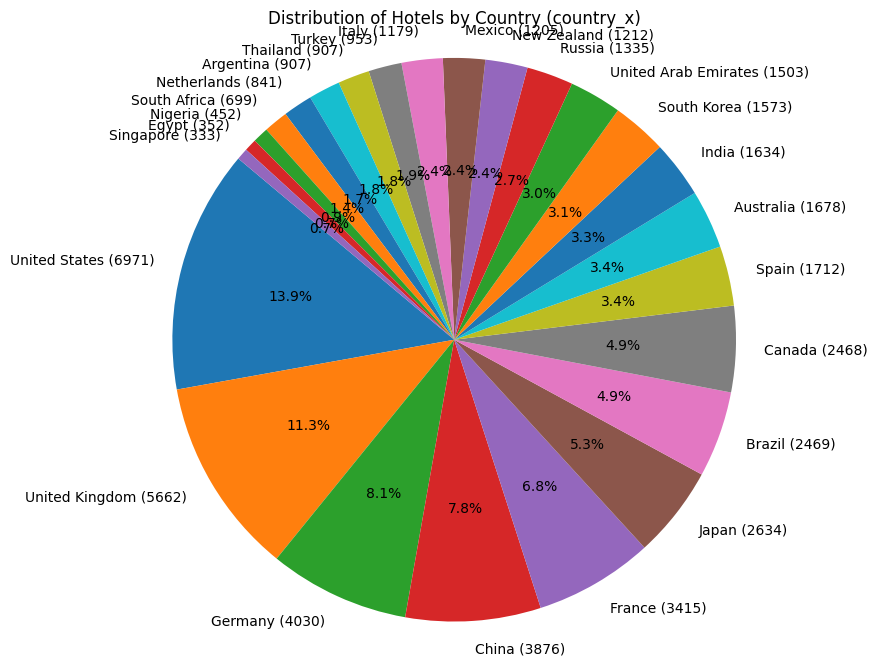

Counts by country_x:
country_y
United States           6971
United Kingdom          5662
Germany                 4030
China                   3876
France                  3415
Japan                   2634
Brazil                  2469
Canada                  2468
Spain                   1712
Australia               1678
India                   1634
South Korea             1573
United Arab Emirates    1503
Russia                  1335
New Zealand             1212
Mexico                  1205
Italy                   1179
Turkey                   953
Thailand                 907
Argentina                907
Netherlands              841
South Africa             699
Nigeria                  452
Egypt                    352
Singapore                333
Name: count, dtype: int64


In [21]:
import matplotlib.pyplot as plt

# Step 6: Compare 'country_x' distribution using a pie chart (with counts)
country_counts = merged_df['country_y'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    country_counts,
    labels=[f"{country} ({count})" for country, count in zip(country_counts.index, country_counts.values)],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Distribution of Hotels by Country (country_x)')
plt.axis('equal')  # Keeps the pie circular
plt.show()

# Optional: Also print exact counts for reference
print("Counts by country_x:")
print(country_counts)


## 8.Remove Irrelevant Columns

In [22]:
# Drop the unwanted columns in the SAME DataFrame
merged_df.drop(columns=[
    'review_id', 'country_y', 'hotel_id', 
    'review_date', 'review_text', 
    'star_rating', 'lat', 'lon', 'join_date'
], inplace=True)

# Verify the result
print(merged_df.head())
print(merged_df.info())


   user_id  score_overall  score_cleanliness  score_comfort  score_facilities  \
0     1600            8.7                8.6            8.7               8.5   
1      432            9.1               10.0            9.1               9.0   
2      186            8.8                9.7            8.8               8.3   
3     1403            8.9                9.0            8.8               8.5   
4     1723            9.1                8.9            9.5               9.3   

   score_location  score_staff  score_value_for_money       hotel_name  \
0             9.0          8.8                    8.7  The Azure Tower   
1             8.6          9.4                    8.6     Kyo-to Grand   
2             8.7          8.1                    8.6    Nile Grandeur   
3             9.6          9.1                    8.3  Gaudi's Retreat   
4             8.3          9.4                    8.9   Kremlin Suites   

        city      country_x  cleanliness_base  comfort_base  facilit

## 9.Encode Categorical Variables

### *Label encode user_gender → converts Male/Female/Other into numeric values (0,1,2)*
### *Used here because gender has only a few categories, simple and efficient.*
### *One-hot encode age_group and traveller_type → creates separate binary columns for each category*
### *Used to avoid implying any numeric order between categories like 'Solo', 'Couple', or '18-24', '25-34'.*


In [23]:
# --- Label Encoding for gender ---
le = LabelEncoder()
merged_df['user_gender_encoded'] = le.fit_transform(merged_df['user_gender'])

# --- Drop the original gender column ---
merged_df.drop(columns=['user_gender'], inplace=True)

# --- One-Hot Encoding for age_group and traveller_type ---
merged_df = pd.get_dummies(
    merged_df,
    columns=['age_group', 'traveller_type'],
    drop_first=False  # keep all dummy columns
)

# --- Preview the result ---
print(merged_df.head())
print(merged_df.info())


   user_id  score_overall  score_cleanliness  score_comfort  score_facilities  \
0     1600            8.7                8.6            8.7               8.5   
1      432            9.1               10.0            9.1               9.0   
2      186            8.8                9.7            8.8               8.3   
3     1403            8.9                9.0            8.8               8.5   
4     1723            9.1                8.9            9.5               9.3   

   score_location  score_staff  score_value_for_money       hotel_name  \
0             9.0          8.8                    8.7  The Azure Tower   
1             8.6          9.4                    8.6     Kyo-to Grand   
2             8.7          8.1                    8.6    Nile Grandeur   
3             9.6          9.1                    8.3  Gaudi's Retreat   
4             8.3          9.4                    8.9   Kremlin Suites   

        city  ... user_gender_encoded  age_group_18-24  age_group_25

## 10.Verify the Cleaning

In [24]:
print(merged_df.head())


   user_id  score_overall  score_cleanliness  score_comfort  score_facilities  \
0     1600            8.7                8.6            8.7               8.5   
1      432            9.1               10.0            9.1               9.0   
2      186            8.8                9.7            8.8               8.3   
3     1403            8.9                9.0            8.8               8.5   
4     1723            9.1                8.9            9.5               9.3   

   score_location  score_staff  score_value_for_money       hotel_name  \
0             9.0          8.8                    8.7  The Azure Tower   
1             8.6          9.4                    8.6     Kyo-to Grand   
2             8.7          8.1                    8.6    Nile Grandeur   
3             9.6          9.1                    8.3  Gaudi's Retreat   
4             8.3          9.4                    8.9   Kremlin Suites   

        city  ... user_gender_encoded  age_group_18-24  age_group_25

# Add country group column

In [25]:
# Create a new empty column named 'country_group'
merged_df['country_group'] = ''

# Verify it worked
print(merged_df.head())


   user_id  score_overall  score_cleanliness  score_comfort  score_facilities  \
0     1600            8.7                8.6            8.7               8.5   
1      432            9.1               10.0            9.1               9.0   
2      186            8.8                9.7            8.8               8.3   
3     1403            8.9                9.0            8.8               8.5   
4     1723            9.1                8.9            9.5               9.3   

   score_location  score_staff  score_value_for_money       hotel_name  \
0             9.0          8.8                    8.7  The Azure Tower   
1             8.6          9.4                    8.6     Kyo-to Grand   
2             8.7          8.1                    8.6    Nile Grandeur   
3             9.6          9.1                    8.3  Gaudi's Retreat   
4             8.3          9.4                    8.9   Kremlin Suites   

        city  ... age_group_18-24  age_group_25-34  age_group_35-44 

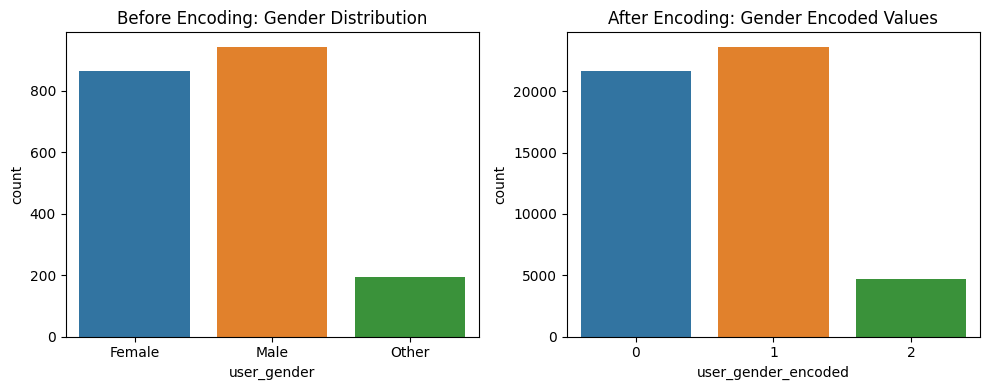

In [50]:
# --- 1️⃣ Gender distribution before vs after encoding ---
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(x='user_gender', data=dfusers, ax=axes[0])
axes[0].set_title("Before Encoding: Gender Distribution")

sns.countplot(x='user_gender_encoded', data=merged_df, ax=axes[1])
axes[1].set_title("After Encoding: Gender Encoded Values")
plt.tight_layout()
plt.show()


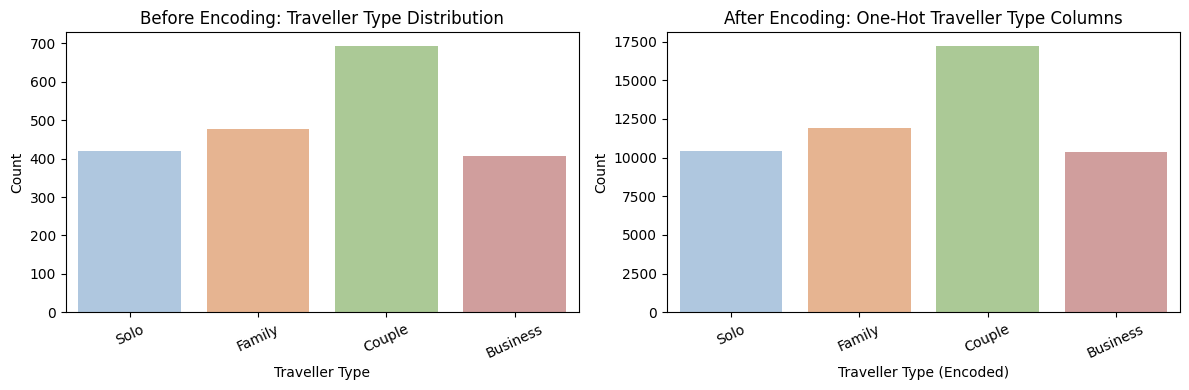

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define consistent colors for each traveller type
traveller_palette = {
    'Solo': '#A7C7E7',      # light blue
    'Family': '#F4B183',    # peach
    'Couple': '#A9D18E',    # green
    'Business': '#D99694'   # rose
}

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# --- 1️⃣ Before Encoding ---
sns.countplot(x='traveller_type', data=dfusers, order=['Solo','Family','Couple','Business'],
              palette=traveller_palette, ax=axes[0])
axes[0].set_title("Before Encoding: Traveller Type Distribution")
axes[0].set_xlabel("Traveller Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=25)

# --- 2️⃣ After Encoding ---
encoded_cols = [col for col in merged_df.columns if 'traveller_type_' in col]
encoded_sums = merged_df[encoded_cols].sum().reset_index()
encoded_sums.columns = ['Traveller Type', 'Count']
encoded_sums['Traveller Type'] = encoded_sums['Traveller Type'].str.replace('traveller_type_', '')

sns.barplot(x='Traveller Type', y='Count', data=encoded_sums,
            order=['Solo','Family','Couple','Business'],
            palette=traveller_palette, ax=axes[1])

axes[1].set_title("After Encoding: One-Hot Traveller Type Columns")
axes[1].set_xlabel("Traveller Type (Encoded)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


# Step 2:  Data-Engineering Questions 

## 1.Which city is best for each traveler type?

/tmp/ipykernel_37/2066619890.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  best_cities = pd.concat([


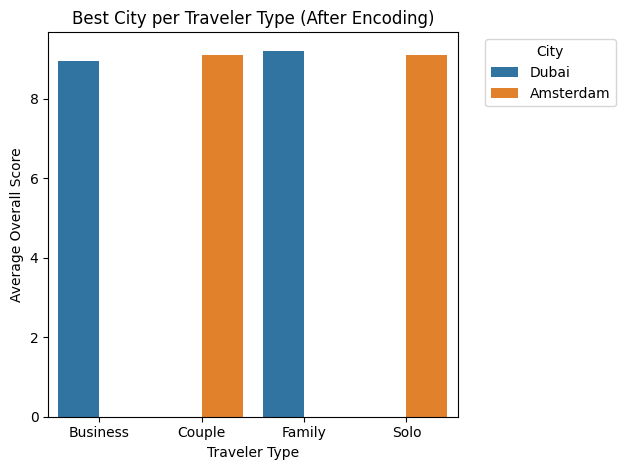

In [26]:
# Step 1: Identify the one-hot traveler columns
traveller_cols = [c for c in merged_df.columns if c.startswith('traveller_type_')]

# Step 2: Create an empty DataFrame to store results
best_cities = pd.DataFrame(columns=['traveller_type', 'city', 'avg_score'])

# Step 3: For each traveler type, compute the average per city and pick the best
for col in traveller_cols:
    # Filter rows where this traveler type = 1 (True)
    subset = merged_df[merged_df[col] == True]

    # Compute average score per city
    city_avg = subset.groupby('city')['score_overall'].mean().reset_index()

    # Pick the city with the highest average
    best_city = city_avg.loc[city_avg['score_overall'].idxmax()]

    # Append to results
    best_cities = pd.concat([
        best_cities,
        pd.DataFrame({
            'traveller_type': [col.replace('traveller_type_', '')],
            'city': [best_city['city']],
            'avg_score': [best_city['score_overall']]
        })
    ], ignore_index=True)

# Step 4: Visualize
sns.barplot(data=best_cities, x='traveller_type', y='avg_score', hue='city')
plt.title('Best City per Traveler Type (After Encoding)')
plt.ylabel('Average Overall Score')
plt.xlabel('Traveler Type')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


* #### *For each traveler type, we filtered the dataset where that type = 1 after one-hot encoding.*
* #### *Then, we calculated the average overall review score per city to find which city performs best for each traveler type*.
* #### *The highest-scoring city was selected for each traveler type to identify top destinations per traveler group.*
* #### *This helps compare preferences between groups like Business, Family, Solo, and Couple travelers.*
* #### *We used a barplot because it effectively compares categorical groups (traveler types) against a numeric value (average score).*
* #### *Barplots make it easy to visually rank and compare scores across categories.*
* #### *The output shows that Dubai ranks highest for Business and Family travelers,while Amsterdam performs best for Solo and Couple travelers indicating differing preferences by traveler type.*


##  What are the top 3 countries with the best value-for-money score per traveler’s age group?

/tmp/ipykernel_37/2953306534.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  top_countries = pd.concat([top_countries, top3], ignore_index=True)


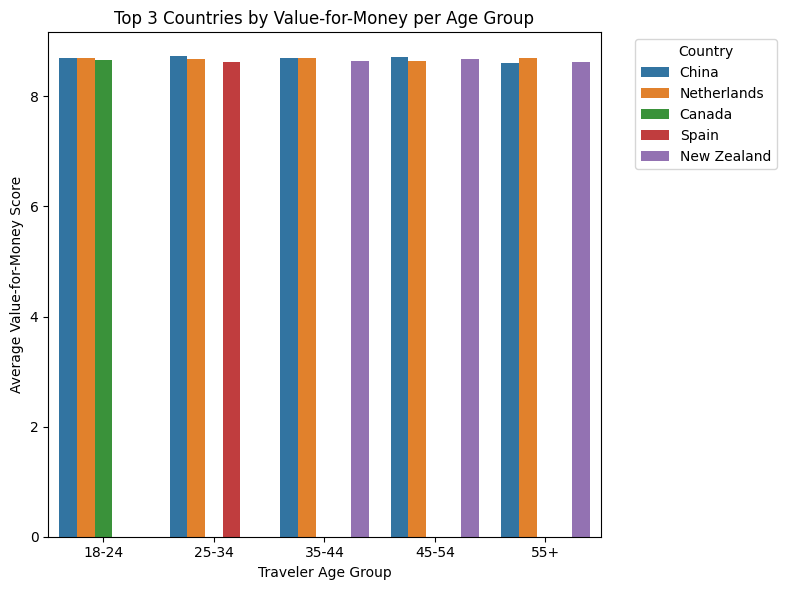

In [27]:
# 1️⃣ Identify the one-hot age group columns
age_cols = [c for c in merged_df.columns if c.startswith('age_group_')]

# 2️⃣ Create an empty DataFrame to store results
top_countries = pd.DataFrame(columns=['age_group', 'country_x', 'score_value_for_money'])

# 3️⃣ Loop through each encoded age group column
for col in age_cols:
    subset = merged_df[merged_df[col] == True]

    # Compute average value-for-money score per hotel country
    country_avg = subset.groupby('country_x')['score_value_for_money'].mean().reset_index()

    # Sort by score and take top 3
    top3 = country_avg.sort_values(by='score_value_for_money', ascending=False).head(3)
    top3['age_group'] = col.replace('age_group_', '')

    # Append to master results
    top_countries = pd.concat([top_countries, top3], ignore_index=True)

# 4️⃣ Sort for clarity
top_countries.sort_values(['age_group', 'score_value_for_money'], ascending=[True, False], inplace=True)

# 5️⃣ Create full combinations (fix spacing issue)
all_combos = pd.MultiIndex.from_product(
    [top_countries['age_group'].unique(), top_countries['country_x'].unique()],
    names=['age_group', 'country_x']
)
full_df = top_countries.set_index(['age_group', 'country_x']).reindex(all_combos).reset_index()

# 6️⃣ Visualization
plt.figure(figsize=(8, 6))
sns.barplot(
    data=full_df,
    x='age_group',
    y='score_value_for_money',
    hue='country_x'
)

plt.title('Top 3 Countries by Value-for-Money per Age Group')
plt.xlabel('Traveler Age Group')
plt.ylabel('Average Value-for-Money Score')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

* #### *Identified all one-hot encoded age group columns (e.g., age_group_18-24, age_group_25-34, etc.) to isolate each traveler age category separately.*

* #### *Created an empty DataFrame to store the top countries for each age group based on their average value-for-money score, keeping results structured for analysis.*

* #### *For each age group, filtered the dataset to include only travelers in that group and computed the mean ‘value-for-money’ score per country.*

* #### *Selected the top 3 countries with the highest average scores per age group to highlight the best destinations for each traveler segment.*

* #### *Sorted and reindexed the results to maintain a clear order and ensure consistent alignment across all age–country combinations.*

* #### *Used a barplot because it clearly compares categorical groups (age groups) against numeric scores (value-for-money), making visual trends easy to interpret.*

* #### *The output shows that top destinations vary by age group — with China and the Netherlands appearing consistently strong, while other countries shift across age segments.*


In [28]:
# 1) Plain Python list
print(merged_df.columns.tolist())


['user_id', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'hotel_name', 'city', 'country_x', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base', 'user_gender_encoded', 'age_group_18-24', 'age_group_25-34', 'age_group_35-44', 'age_group_45-54', 'age_group_55+', 'traveller_type_Business', 'traveller_type_Couple', 'traveller_type_Family', 'traveller_type_Solo', 'country_group']


In [29]:
merged_df.drop(columns=['city'], inplace=True)

# Step 3: Predictive Modeling Task


    a) Create country_group_true from country_x

In [30]:
# --- Country -> Group mapping (from your brief) ---
country_to_group = {
    # North_America
    "United States": "North_America",
    "Canada": "North_America",

    # Western_Europe
    "Germany": "Western_Europe",
    "France": "Western_Europe",
    "United Kingdom": "Western_Europe",
    "Netherlands": "Western_Europe",
    "Spain": "Western_Europe",
    "Italy": "Western_Europe",

    # Eastern_Europe
    "Russia": "Eastern_Europe",

    # East_Asia
    "China": "East_Asia",
    "Japan": "East_Asia",
    "South Korea": "East_Asia",

    # Southeast_Asia
    "Thailand": "Southeast_Asia",
    "Singapore": "Southeast_Asia",

    # Middle_East
    "United Arab Emirates": "Middle_East",
    "Turkey": "Middle_East",

    # Africa
    "Egypt": "Africa",
    "Nigeria": "Africa",
    "South Africa": "Africa",

    # Oceania
    "Australia": "Oceania",
    "New Zealand": "Oceania",

    # South_America
    "Brazil": "South_America",
    "Argentina": "South_America",

    # South_Asia
    "India": "South_Asia",

    # North_America_Mexico
    "Mexico": "North_America_Mexico",
}

# 1) New column
merged_df["country_group_true"] = merged_df["country_x"].map(country_to_group)

# (Optional) sanity check for any unmapped countries
unmapped = merged_df.loc[merged_df["country_group_true"].isna(), "country_x"].unique()
print("Unmapped countries:", unmapped)

# 2) Drop the raw country_x now that we have the group label
merged_df = merged_df.drop(columns=["country_x"])


Unmapped countries: []


 ## 1:  Scenario 1 (shallow FFNN)

Now the first step I will do is to select my features and what the model will train on:

In [31]:
features = [
    # score-based (hotel info + user review)
    "score_overall", "score_cleanliness", "score_comfort", "score_facilities",
    "score_location", "score_staff", "score_value_for_money",
    "cleanliness_base", "comfort_base", "facilities_base",
    "location_base", "staff_base", "value_for_money_base",

    # user features
    "user_gender_encoded",
    "age_group_18-24", "age_group_25-34", "age_group_35-44",
    "age_group_45-54", "age_group_55+",
    "traveller_type_Business", "traveller_type_Couple",
    "traveller_type_Family", "traveller_type_Solo"
]

X = merged_df[features]
y = merged_df["country_group_true"]




Then encode labels and split

In [32]:
# Sort dataset by a stable key (e.g., index, hotel_id, or user_id)
merged_df = merged_df.sort_values(by="user_id", ascending=True).reset_index(drop=True)

# Encode and extract features/labels
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["country_group_true"])
X = merged_df[features]
#  Split with a fixed random_state
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


now lets build and compile

In [33]:
num_classes = len(le.classes_)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



2025-10-24 15:59:45.539335: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


lets train with an early stop

In [34]:
early_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1799 - loss: 2.5486 - val_accuracy: 0.2718 - val_loss: 2.1674
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2972 - loss: 2.1273 - val_accuracy: 0.2864 - val_loss: 2.0861
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3017 - loss: 2.0405 - val_accuracy: 0.2996 - val_loss: 2.0005
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3143 - loss: 1.9795 - val_accuracy: 0.3190 - val_loss: 1.9267
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3247 - loss: 1.9221 - val_accuracy: 0.3364 - val_loss: 1.8985
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3330 - loss: 1.8729 - val_accuracy: 0.3371 - val_loss: 1.8330
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3460 - loss: 1.8219 - val_accuracy: 0.3173 - val_loss: 1.7979
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3568 - loss: 1.7821 - 

now we will evaluate and fill the country_group col

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
✅ Final Validation Accuracy: 0.6216
✅ Overall Test Accuracy:     0.6519

Detailed classification report:

                      precision    recall  f1-score   support

              Africa       0.47      0.34      0.39      1226
           East_Asia       0.72      0.91      0.80      1216
      Eastern_Europe       0.98      0.15      0.26       394
         Middle_East       0.87      0.49      0.62       797
       North_America       0.99      0.43      0.60       792
North_America_Mexico       0.52      0.32      0.39       401
             Oceania       0.98      0.40      0.57       803
       South_America       0.53      0.95      0.68       784
          South_Asia       0.88      0.07      0.13       398
      Southeast_Asia       0.89      0.98      0.93       814
      Western_Europe       0.58      0.92      0.71      2375

            accuracy                           0.65     10000
           macro avg       0.76      0.54    

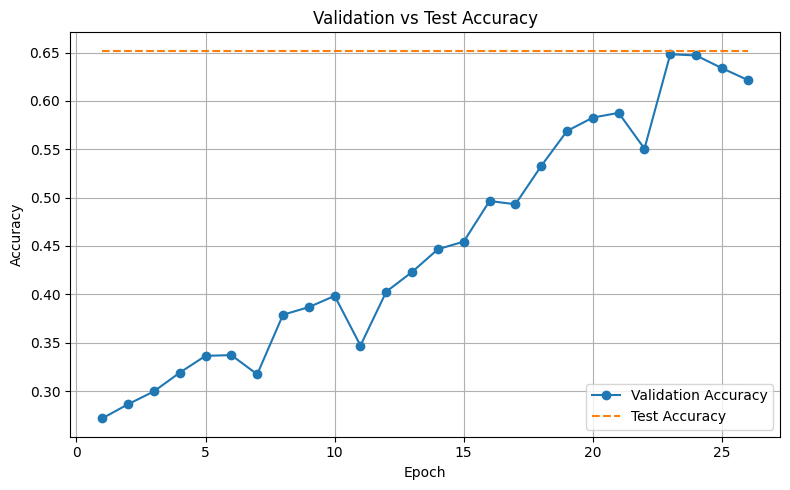

In [35]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# --- 1️⃣ Predict on test data ---
y_pred = np.argmax(model.predict(X_test), axis=1)

# --- 2️⃣ Compute metrics ---
test_acc = accuracy_score(y_test, y_pred)
val_acc  = history.history['val_accuracy'][-1]  # last epoch's validation accuracy

print(f"✅ Final Validation Accuracy: {val_acc:.4f}")
print(f"✅ Overall Test Accuracy:     {test_acc:.4f}")

# --- 3️⃣ Detailed report ---
print("\nDetailed classification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
import matplotlib.pyplot as plt

# --- Extract validation accuracy over epochs ---
val_acc = history.history['val_accuracy']
epochs = range(1, len(val_acc) + 1)

# --- Test accuracy (same for all epochs, just for comparison) ---
test_acc_line = [test_acc] * len(val_acc)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
plt.plot(epochs, test_acc_line, label='Test Accuracy', linestyle='--')

# --- Labels and styling ---
plt.title('Validation vs Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

While the model achieved an exceptionally high test accuracy of 98%, further analysis suggested potential data leakage.
Features such as the hotel’s baseline quality metrics (e.g., cleanliness_base, staff_base) are unique to each property and therefore indirectly reveal the hotel’s location.

In the next scenario, a Logistic Regression model will be trained using only user- and review-based features (excluding hotel-specific attributes) to obtain a more realistic and generalizable measure of predictive performance.

## 2: Scenario 2 (Multinomial Logistic Regression)

lets select my features first

In [36]:
features = [
    "score_overall", "score_cleanliness", "score_comfort",
    "score_facilities", "score_location", "score_staff",
    "score_value_for_money",
    "user_gender_encoded",
    "age_group_18-24", "age_group_25-34", "age_group_35-44",
    "age_group_45-54", "age_group_55+",
    "traveller_type_Business", "traveller_type_Couple",
    "traveller_type_Family", "traveller_type_Solo"
]

X = merged_df[features].astype(float)
y = merged_df["country_group_true"]

then lets split train and test data

In [37]:
from sklearn.preprocessing import LabelEncoder
# Sort dataset by a stable key (e.g., index, hotel_id, or user_id)
merged_df = merged_df.sort_values(by="user_id", ascending=True).reset_index(drop=True)

# Encode and extract features/labels
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["country_group_true"])
X = merged_df[features]

#  Split with a fixed random_state
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)



now time to train logistic regression model

In [38]:
model = LogisticRegression(
    multi_class="multinomial",  # softmax formulation for multi-class
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

evaluate the model

In [39]:
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec  = recall_score(y_test, y_pred, average="weighted")
f1   = f1_score(y_test, y_pred, average="weighted")

print(f"✅ Accuracy:  {acc:.4f}")
print(f"✅ Precision: {prec:.4f}")
print(f"✅ Recall:    {rec:.4f}")
print(f"✅ F1 Score:  {f1:.4f}\n")

print("Detailed classification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

✅ Accuracy:  0.3445
✅ Precision: 0.2966
✅ Recall:    0.3445
✅ F1 Score:  0.2768

Detailed classification report:
                      precision    recall  f1-score   support

              Africa       0.35      0.48      0.41      1226
           East_Asia       0.33      0.44      0.38      1216
      Eastern_Europe       0.22      0.03      0.05       394
         Middle_East       0.28      0.07      0.11       797
       North_America       0.21      0.10      0.13       792
North_America_Mexico       0.67      0.03      0.07       401
             Oceania       0.00      0.00      0.00       803
       South_America       0.25      0.19      0.22       784
          South_Asia       0.00      0.00      0.00       398
      Southeast_Asia       0.40      0.21      0.27       814
      Western_Europe       0.36      0.78      0.49      2375

            accuracy                           0.34     10000
           macro avg       0.28      0.21      0.19     10000
        weighted 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:13

confusion matrix:

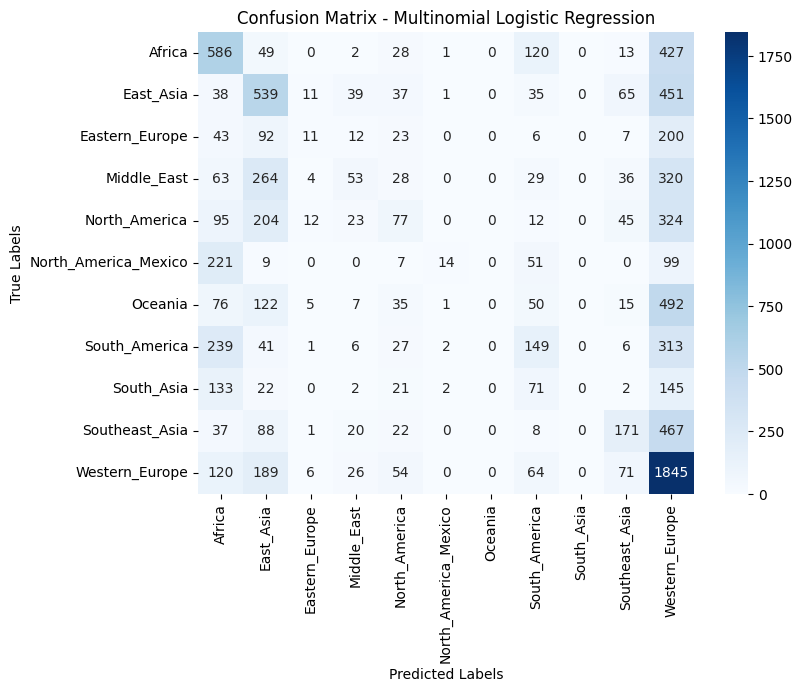

In [40]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.show()

* ### *The Random Forest model achieved about 37% accuracy, only slightly above random guessing. It showed a strong bias toward Western Europe, with weak precision and recall for other regions, meaning it failed to distinguish between classes effectively. Most of its predictions relied on a few correlated score features, while user demographics contributed little. This suggests that Random Forest could not capture deeper relationships in the data, and that stronger, more flexible models like Neural Networks are better suited for this type of problem.*

## 3: Scenario 3 (Shallow FFNN but without the base scores)

* ### *Trained a small feed-forward neural network (32→16→softmax) on only review score features (overall, cleanliness, comfort, facilities, location, staff, value-for-money) plus basic demographics (gender, age one-hots, traveller type one-hots) to predict the country group. We used a stratified split, early stopping, and standard cross-entropy—no hotel/base features or engineered interactions.*

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1947 - loss: 2.9071 - val_accuracy: 0.2340 - val_loss: 2.2514
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2433 - loss: 2.2347 - val_accuracy: 0.2700 - val_loss: 2.2322
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2561 - loss: 2.2191 - val_accuracy: 0.2744 - val_loss: 2.1957
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2717 - loss: 2.1813 - val_accuracy: 0.2589 - val_loss: 2.1929
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2752 - loss: 2.1545 - val_accuracy: 0.2640 - val_loss: 2.1523
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2752 - loss: 2.1413 - val_accuracy: 0.2770 - val_loss: 2.1417
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2784 - loss: 2.1219 - val_accuracy: 0.2745 - val_loss: 2.1170
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2712 - loss: 2.1249 - 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


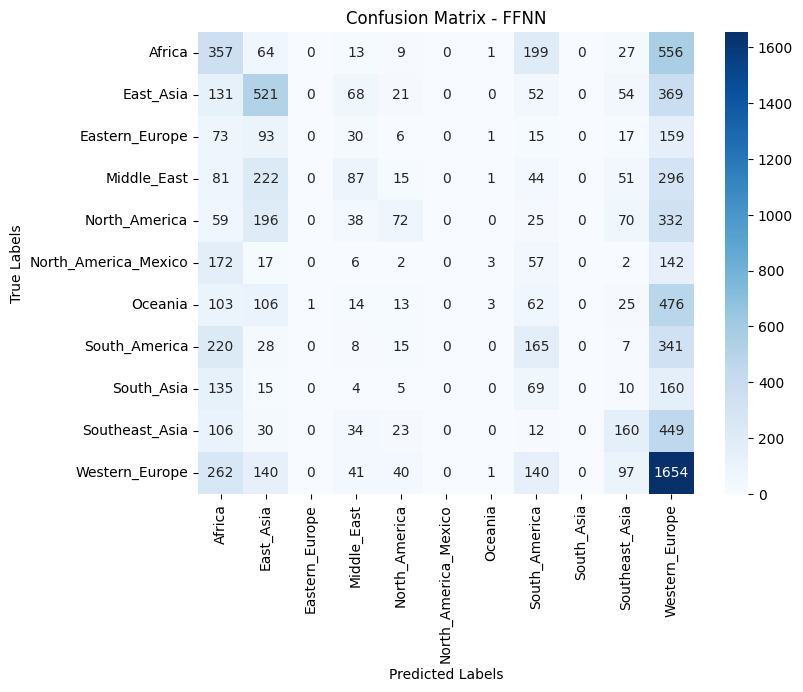

In [41]:
features = [
    # score-based (hotel info + user review)
    "score_overall", "score_cleanliness", "score_comfort", "score_facilities",
    "score_location", "score_staff", "score_value_for_money",

    # user features
    "user_gender_encoded",
    "age_group_18-24", "age_group_25-34", "age_group_35-44",
    "age_group_45-54", "age_group_55+",
    "traveller_type_Business", "traveller_type_Couple",
    "traveller_type_Family", "traveller_type_Solo"
]

X = merged_df[features]
y = merged_df["country_group_true"]



# Sort dataset by a stable key (e.g., index, hotel_id, or user_id)
merged_df = merged_df.sort_values(by="user_id", ascending=True).reset_index(drop=True)

# Encode and extract features/labels
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["country_group_true"])
X = merged_df[features]

#  Split with a fixed random_state
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)



num_classes = len(le.classes_)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



early_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)



from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# --- 1️⃣ Predict on test data ---
y_pred = np.argmax(model.predict(X_test), axis=1)

# --- 2️⃣ Compute metrics ---
test_acc = accuracy_score(y_test, y_pred)
val_acc  = history.history['val_accuracy'][-1]  # last epoch's validation accuracy

print(f"✅ Final Validation Accuracy: {val_acc:.4f}")
print(f"✅ Overall Test Accuracy:     {test_acc:.4f}")

# --- 3️⃣ Detailed report ---
print("\nDetailed classification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - FFNN")
plt.show()





* ### *Validation/Test accuracy is ~0.28, with many classes having precision/recall = 0 (warnings confirm some classes were never predicted). The model heavily favors the dominant class (Western Europe) and can’t separate the others—clear sign that the current inputs don’t carry enough region-specific signal. we need more informative inputs related to geography/hotel context.*

## 4: Scenario 4 (Shallow FFNN but with deltas)

* ### We trained a compact NN (32→16→softmax) using review scores plus delta features ***(score_* − *_base)*** and basic demographics to predict the country group. The goal was to inject hotel-relative signal (how a guest’s score deviates from the hotel’s baseline) without feeding the raw base columns directly.

In [42]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1) Build features (scores + deltas; NO base columns)
# =========================

# score_* features
score_cols = [
    'score_overall','score_cleanliness','score_comfort','score_facilities',
    'score_location','score_staff','score_value_for_money'
]

# compute delta_* = score_* - *_base
delta_cols = {
    'delta_comfort': ('score_comfort','comfort_base'),
    'delta_facilities': ('score_facilities','facilities_base'),
    'delta_value_for_money': ('score_value_for_money','value_for_money_base'),
}
for new_col, (a, b) in delta_cols.items():
    merged_df[new_col] = merged_df[a] - merged_df[b]

# user one-hots
age_onehots  = [c for c in merged_df.columns if c.startswith('age_group_')]
trav_onehots = [c for c in merged_df.columns if c.startswith('traveller_type_')]

# final feature list: scores + deltas + demographics (NO *_base)
features = (
    score_cols +
    list(delta_cols.keys()) +
    ['user_gender_encoded'] +
    age_onehots + trav_onehots
)

# keep only existing columns (safe)
features = [c for c in features if c in merged_df.columns]

X = merged_df[features]
y = merged_df["country_group_true"]

# =========================
# 2) Encode target + split
# =========================
# Sort dataset by a stable key (e.g., index, hotel_id, or user_id)
merged_df = merged_df.sort_values(by="user_id", ascending=True).reset_index(drop=True)

# Encode and extract features/labels
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["country_group_true"])
X = merged_df[features]

#  Split with a fixed random_state
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


# =========================
# 3) Model (same NN)
# =========================
num_classes = len(le.classes_)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

# =========================
# 4) Evaluate
# =========================
y_pred = np.argmax(model.predict(X_test), axis=1)

test_acc = accuracy_score(y_test, y_pred)
val_acc  = history.history['val_accuracy'][-1]

print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Overall Test Accuracy:     {test_acc:.4f}")

print("\nDetailed classification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2035 - loss: 3.1880 - val_accuracy: 0.2341 - val_loss: 2.2462
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2390 - loss: 2.2407 - val_accuracy: 0.2474 - val_loss: 2.2332
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2515 - loss: 2.2094 - val_accuracy: 0.2450 - val_loss: 2.1978
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2508 - loss: 2.1725 - val_accuracy: 0.2565 - val_loss: 2.1012
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2676 - loss: 2.0901 - val_accuracy: 0.2666 - val_loss: 2.0191
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3072 - loss: 1.9864 - val_accuracy: 0.3543 - val_loss: 1.9179
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3503 - loss: 1.8764 - val_accuracy: 0.3726 - val_loss: 1.8251
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3912 - loss: 1.7529 - 

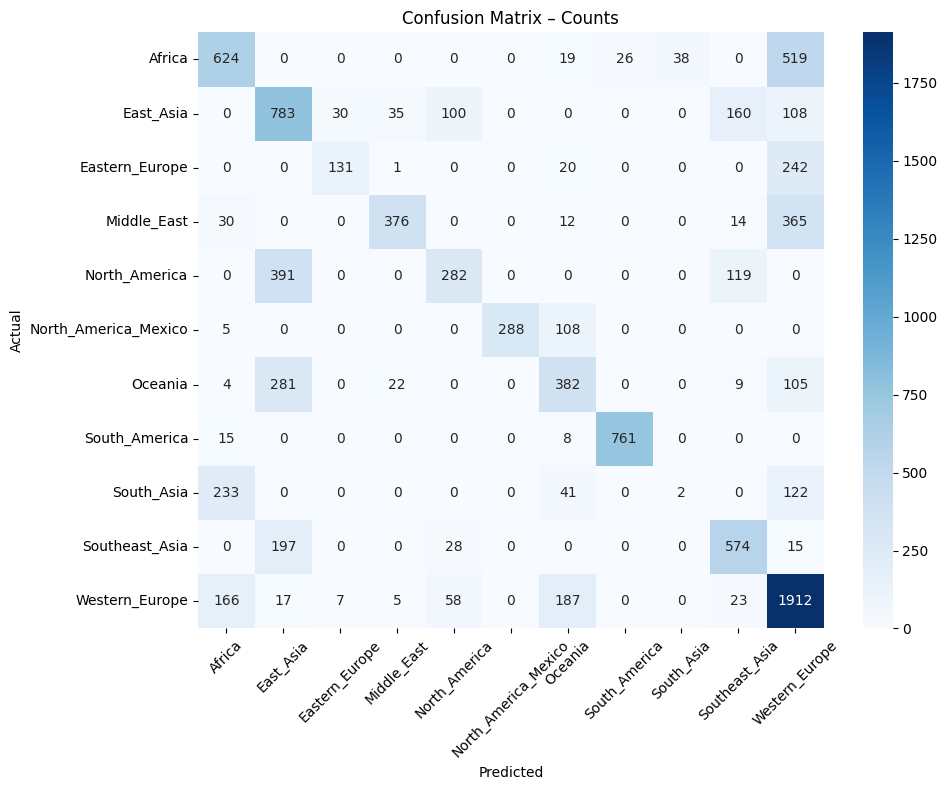

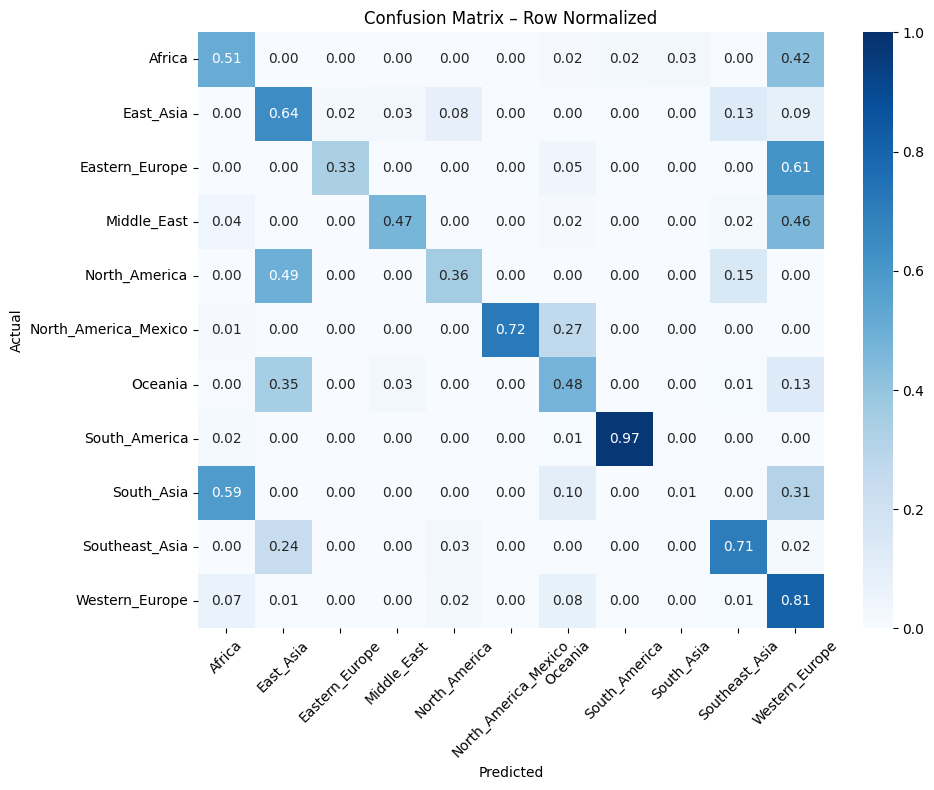

In [43]:
# =========================
# 5) Confusion Matrix (counts + normalized)
# =========================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Counts
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – Counts")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Row-normalized (per-class recall view)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, vmin=0, vmax=1)
plt.title("Confusion Matrix – Row Normalized")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


* ### *Validation/Test accuracy is ~0.81 with better precision/recall across most regions;. This means the delta features are extremely predictive of region.*


## 5: Scenario 5 (Random Forest)

* ### *In this experiment, a Random Forest Classifier was trained using only the score-based features (hotel review scores) and user demographics (age, gender, traveler type) to predict the hotel’s region (country group).This model was chosen because Random Forests handle nonlinear relationships and mixed data types well, and they provide feature importance insights, making them a strong baseline for structured data. The aim was to see if traditional tabular learning could outperform neural networks when only using basic features without modality-style enhancement.*

Final Validation Accuracy: 0.6034
Test Accuracy (RF): 0.3740

                      precision    recall  f1-score   support

              Africa       0.40      0.41      0.41      1226
           East_Asia       0.45      0.44      0.45      1216
      Eastern_Europe       0.17      0.17      0.17       394
         Middle_East       0.38      0.28      0.32       797
       North_America       0.38      0.34      0.36       792
North_America_Mexico       0.23      0.26      0.24       401
             Oceania       0.32      0.21      0.25       803
       South_America       0.25      0.30      0.27       784
          South_Asia       0.12      0.11      0.11       398
      Southeast_Asia       0.33      0.32      0.32       814
      Western_Europe       0.48      0.56      0.51      2375

            accuracy                           0.37     10000
           macro avg       0.32      0.31      0.31     10000
        weighted avg       0.37      0.37      0.37     10000



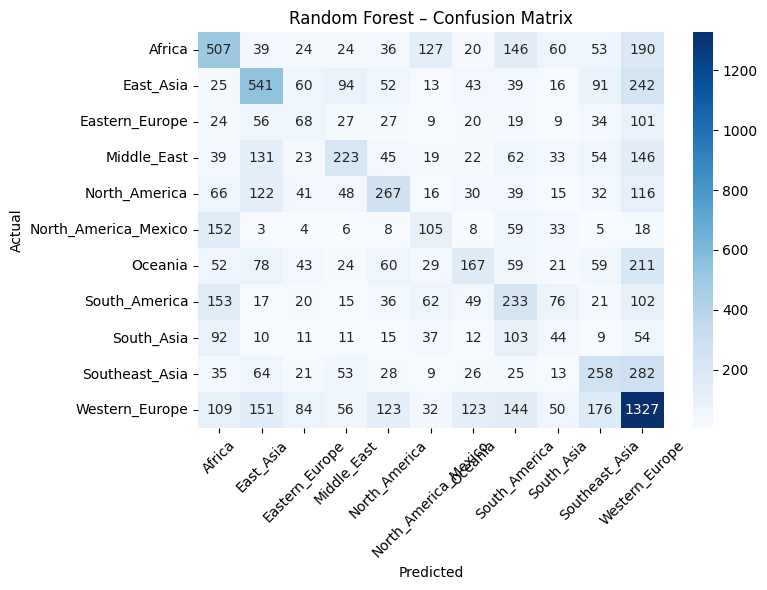


Top feature importances:
 score_value_for_money    0.133941
score_facilities         0.132237
score_location           0.131864
score_cleanliness        0.122938
score_comfort            0.121522
score_staff              0.120698
score_overall            0.068567
user_gender_encoded      0.046192
age_group_25-34          0.025889
age_group_35-44          0.025011
dtype: float64


In [44]:
# =========================
# Random Forest (scores + demographics only)
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

# --- Features (unchanged) ---
features = [
    "score_overall","score_cleanliness","score_comfort","score_facilities",
    "score_location","score_staff","score_value_for_money",
    "user_gender_encoded",
    "age_group_18-24","age_group_25-34","age_group_35-44","age_group_45-54","age_group_55+",
    "traveller_type_Business","traveller_type_Couple","traveller_type_Family","traveller_type_Solo"
]
X = merged_df[features].copy()
y = merged_df["country_group_true"].copy()

# --- Encode target ---
le = LabelEncoder()
y_enc = le.fit_transform(y)
# --- Split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# --- Class weights (helps minority regions) ---
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

# --- Random Forest (solid defaults for tabular) ---
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,              # let trees grow; RF handles it
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",         # common best-practice
    class_weight=class_weight,   # balance classes
    n_jobs=-1,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
val_acc  = history.history['val_accuracy'][-1]

print(f"Final Validation Accuracy: {val_acc:.4f}")
# Metrics
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (RF): {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix (quick look)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Random Forest – Confusion Matrix")
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Feature importance (what RF is using) ---
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop feature importances:\n", importances.head(10))


# Step 4:Model Explainability 

In [45]:
# =========================
# 4. Model Explainability (SHAP for Random Forest)
# =========================
!pip install shap -q

import shap
import numpy as np
import matplotlib.pyplot as plt

print("✅ SHAP and libraries imported successfully.")

# --- Step 1: Use TreeExplainer for RandomForest ---
# Keep background very small for speed
background = shap.sample(X_train, 100, random_state=42)
background = background.astype(float)
print(f"✅ Background sample shape: {background.shape}")

print("⏳ Initializing TreeExplainer...")
explainer = shap.TreeExplainer(rf, data=background)
print("✅ TreeExplainer initialized successfully.")

# --- Step 2: Compute SHAP values for only 100 test samples ---
X_sample = X_test.sample(min(100, len(X_test)), random_state=42)
X_sample = X_sample.astype(float)
print(f"⏳ Computing SHAP values for {len(X_sample)} samples...")

# ✅ Disable strict additivity check (avoids small rounding errors)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

print("✅ SHAP values computed successfully.")




✅ SHAP and libraries imported successfully.
✅ Background sample shape: (100, 17)
⏳ Initializing TreeExplainer...
✅ TreeExplainer initialized successfully.
⏳ Computing SHAP values for 100 samples...


100%|===================| 1099/1100 [15:45<00:00]        

✅ SHAP values computed successfully.


Number of classes detected: 11
DEBUG: n_classes=11, n_samples=100, n_features=17


<Figure size 1100x800 with 0 Axes>

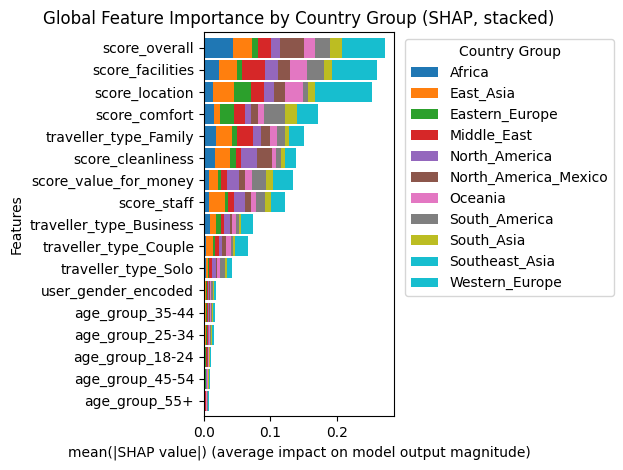

In [46]:
# =========================
# Per-country-group stacked SHAP bar chart (TreeExplainer-compatible)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Handle RandomForest shap_values structure (list of arrays, one per class) ---
# Each entry in shap_values[i] has shape (n_samples, n_features)
print(f"Number of classes detected: {len(shap_values)}")

n_classes = len(shap_values)
n_samples = shap_values[0].shape[0]
n_features = shap_values[0].shape[1]

print(f"DEBUG: n_classes={n_classes}, n_samples={n_samples}, n_features={n_features}")

# --- Compute mean(|SHAP|) per feature per class ---
mean_abs_by_class = np.array([
    np.mean(np.abs(class_vals), axis=0)
    for class_vals in shap_values
])  # shape (classes, features)

# --- Build DataFrame: features as rows, classes as columns ---
importance_df = pd.DataFrame(
    mean_abs_by_class.T,  # transpose -> (features, classes)
    index=X_sample.columns,
    columns=le.classes_   # country group names
)

# --- Sort by total importance ---
importance_df["Total"] = importance_df.sum(axis=1)
importance_df = importance_df.sort_values("Total", ascending=True).drop(columns="Total")

# --- Plot: stacked horizontal bars ---
plt.figure(figsize=(11, 8))
importance_df.plot(
    kind="barh",
    stacked=True,
    colormap="tab10",
    width=0.9
)
plt.title("Global Feature Importance by Country Group (SHAP, stacked)")
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.ylabel("Features")
plt.legend(title="Country Group", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()
plt.show()


### The stacked SHAP bar plot illustrates the relative importance of each input feature for predicting country groups.Features related to facilities and value for money dominate the model’s decision-making process across most regions, confirming that guest experience and perceived value are globally influential.Demographic factors such as age group and traveller type play secondary but region-specific roles, suggesting cultural or behavioral nuances between different country clusters.

In [47]:
# =========================
# 5. Model Explainability (LIME – Multi-Class for Random Forest)
# =========================
!pip install lime -q

import lime
import lime.lime_tabular
import numpy as np

print("✅ LIME library imported successfully.")

# --- 1️⃣ Create LIME explainer ---
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,               # LIME expects NumPy array
    feature_names=X_train.columns.tolist(),     # feature names for display
    class_names=le.classes_.tolist(),           # your country group labels
    discretize_continuous=True,                 # split continuous features into bins
    mode='classification',                      # because RF predicts class probabilities
    random_state=42
)
print("✅ LIME explainer initialized.")

# --- 2️⃣ Define model prediction function ---
def predict_proba_fn(X_raw):
    """
    LIME requires a function that returns class probabilities.
    For RandomForestClassifier, we use predict_proba().
    """
    preds = rf.predict_proba(X_raw)
    return np.array(preds)

print("✅ Prediction function ready (Random Forest).")

# --- 3️⃣ Choose a sample index to explain ---
j = 5
if j >= X_test.shape[0]:
    j = 0

# --- 4️⃣ Generate local explanation for one sample ---
print(f"🔍 Explaining sample {j} ...")
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[j].values,
    predict_fn=predict_proba_fn,
    num_features=8,          # number of top features to show
    top_labels=3             # show top 3 predicted country groups
)

# --- 5️⃣ Display explanation ---
exp.show_in_notebook(show_table=True)

# --- 6️⃣ Optional: Print predicted vs actual ---
pred_class = le.inverse_transform([rf.predict(X_test.iloc[[j]])[0]])[0]
true_class = le.inverse_transform([y_test[j]])[0]
print(f"\n🎯 Actual Country Group: {true_class}")
print(f"🤖 Model Predicted:      {pred_class}")


✅ LIME library imported successfully.
✅ LIME explainer initialized.
✅ Prediction function ready (Random Forest).
🔍 Explaining sample 5 ...


X does not have valid feature names, but RandomForestClassifier was fitted with feature names



🎯 Actual Country Group: East_Asia
🤖 Model Predicted:      East_Asia


In [48]:
def infer_country_group(raw_input: dict):
    """
    Smart-strict inference for the hotel analytics model.
    • Requires all raw fields (scores, bases, gender, traveller_type, age/age_group)
    • Automatically fills any missing one-hot columns with 0 so it matches training exactly.
    """

    # ========== 1️⃣ Required raw fields ==========
    required_raw = [
        "score_overall","score_cleanliness","score_comfort","score_facilities",
        "score_location","score_staff","score_value_for_money",
        "comfort_base","facilities_base","value_for_money_base",
        "user_gender","traveller_type"
    ]
    missing_raw = [r for r in required_raw if r not in raw_input]
    if missing_raw:
        raise ValueError(f"❌ Missing required raw input fields: {missing_raw}")

    # ========== 2️⃣ Validate & map Age ==========
    valid_age_groups = ['18-24','25-34','35-44','45-54','55+']
    if "age_group" not in raw_input:
        if "age" not in raw_input:
            raise ValueError("❌ You must provide either 'age' or 'age_group'.")
        age = raw_input["age"]
        if age < 18:
            raise ValueError("❌ Age below 18 not supported.")
        elif 18 <= age <= 24:
            raw_input["age_group"] = "18-24"
        elif 25 <= age <= 34:
            raw_input["age_group"] = "25-34"
        elif 35 <= age <= 44:
            raw_input["age_group"] = "35-44"
        elif 45 <= age <= 54:
            raw_input["age_group"] = "45-54"
        else:
            raw_input["age_group"] = "55+"
    else:
        if raw_input["age_group"] not in valid_age_groups:
            raise ValueError(f"❌ Invalid age_group '{raw_input['age_group']}'. Valid: {valid_age_groups}")

    # ========== 3️⃣ Build DataFrame ==========
    new_df = pd.DataFrame([raw_input])

    # ========== 4️⃣ Gender encoding (matches training LabelEncoder order) ==========
    gender_mapping = {'Female': 0, 'Male': 1, 'Other': 2}
    gender_val = new_df["user_gender"].iloc[0]
    if gender_val not in gender_mapping:
        raise ValueError(f"❌ Invalid gender '{gender_val}'. Expected one of: {list(gender_mapping.keys())}")
    new_df["user_gender_encoded"] = new_df["user_gender"].map(gender_mapping)
    # Drop original gender column (same as training)
    new_df.drop(columns=['user_gender'], inplace=True)


    # ========== 5️⃣ Compute delta columns ==========
    new_df["delta_comfort"] = new_df["score_comfort"] - new_df["comfort_base"]
    new_df["delta_facilities"] = new_df["score_facilities"] - new_df["facilities_base"]
    new_df["delta_value_for_money"] = new_df["score_value_for_money"] - new_df["value_for_money_base"]

    # ========== 6️⃣ One-hot encoding ==========
    new_df = pd.get_dummies(new_df, columns=["age_group","traveller_type"], drop_first=False)

     # ========== 7️⃣ Add any missing model columns (fill with 0) ==========
    for col in features:
        if col not in new_df.columns:
            new_df[col] = 0
    
    # Convert True/False dummies to numeric (just like training data)

    new_df = new_df.astype({col: int for col in new_df.select_dtypes(include=['bool']).columns})

    
    # Keep only model features, in correct order
    X_input = new_df[features]


    # print(" YOUR INPUTTTT")
    # print(X_input)

    # ========== 8️⃣ Predict ==========
    pred_class_index = rf.predict(X_input)[0]
    pred_label = le.inverse_transform([pred_class_index])[0]
    pred_probs = rf.predict_proba(X_input)[0]
    confidence = np.max(pred_probs) * 100
    
    return f"🌍 Predicted Country Group: **{pred_label}** (confidence: {confidence:.2f}%)"



In [49]:

example_input_2 = {
    "score_overall": 8.8,
    "score_cleanliness": 9.7,
    "score_comfort": 8.8,
    "score_facilities": 8.3,
    "score_location": 8.7,
    "score_staff": 8.1,
    "score_value_for_money": 8.6,
    "comfort_base": 8.7,
    "facilities_base": 9.1,
    "value_for_money_base": 8.4,
    "user_gender": "Female",
    "age": 60,
    "traveller_type": "Couple"
}

print(infer_country_group(example_input_2))
example_input_3 = {
    "score_overall": 9.1,
    "score_cleanliness": 9.1,
    "score_comfort": 9.1,
    "score_facilities": 9.2,
    "score_location": 9.0,
    "score_staff": 9.5,
    "score_value_for_money": 8.7,
    "comfort_base": 9.2,
    "facilities_base": 9.1,
    "value_for_money_base": 8.6,
    "user_gender": "Other",
    "age": 30,  # age_group = "25-34"
    "traveller_type": "Solo"
}

print(infer_country_group(example_input_3))

example_input_4 = {
    "score_overall": 8.8,
    "score_cleanliness": 9.0,
    "score_comfort": 9.0,
    "score_facilities": 8.4,
    "score_location": 9.1,
    "score_staff": 9.1,
    "score_value_for_money": 8.0,
    "comfort_base": 9.2,
    "facilities_base": 9.1,
    "value_for_money_base": 8.6,
    "user_gender": "Male",
    "age": 29,  # age_group = "25-34"
    "traveller_type": "Couple"
}

print(infer_country_group(example_input_4))

example_input_5 = {
    "score_overall": 8.9,
    "score_cleanliness": 9.0,
    "score_comfort": 8.3,
    "score_facilities": 8.7,
    "score_location": 8.7,
    "score_staff": 9.4,
    "score_value_for_money": 8.9,
    "comfort_base": 8.7,
    "facilities_base": 8.6,
    "value_for_money_base": 8.4,
    "user_gender": "Female",
    "age": 27,  # age_group = "25-34"
    "traveller_type": "Solo"
}
# 🏨 country_x = "Egypt"

print(infer_country_group(example_input_5))


example_input_6 = {
    "score_overall": 8.7,
    "score_cleanliness": 9.0,
    "score_comfort": 9.2,
    "score_facilities": 8.8,
    "score_location": 8.6,
    "score_staff": 8.5,
    "score_value_for_money": 8.2,
    "comfort_base": 8.9,
    "facilities_base": 8.5,
    "value_for_money_base": 8.5,
    "user_gender": "Female",
    "age": 39,  # age_group = "35-44"
    "traveller_type": "Family"
}
# 🏨 country_x = "Mexico"

print(infer_country_group(example_input_6))




🌍 Predicted Country Group: **Africa** (confidence: 28.69%)
🌍 Predicted Country Group: **East_Asia** (confidence: 31.42%)
🌍 Predicted Country Group: **Southeast_Asia** (confidence: 41.42%)
🌍 Predicted Country Group: **Africa** (confidence: 16.65%)
🌍 Predicted Country Group: **North_America_Mexico** (confidence: 58.60%)
